In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns

from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")

## create solvent accessibility data

/tmp/ipykernel_29684/166459181.py:89: DtypeWarning: Columns (12,36,42,43,44,45,46,47,48,49,62,77,78,79,80,81,82,83,84,85,92,93,94,100,103,104,108,109,111,112,113,114,115,117,118,119,120,121,123,124,125,127,128,129,130,131,132,133,134,138,139,140,141,142,143,144,154,167,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,233) have mixed types. Specify dtype option on import or set low_memory=False.
  sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')


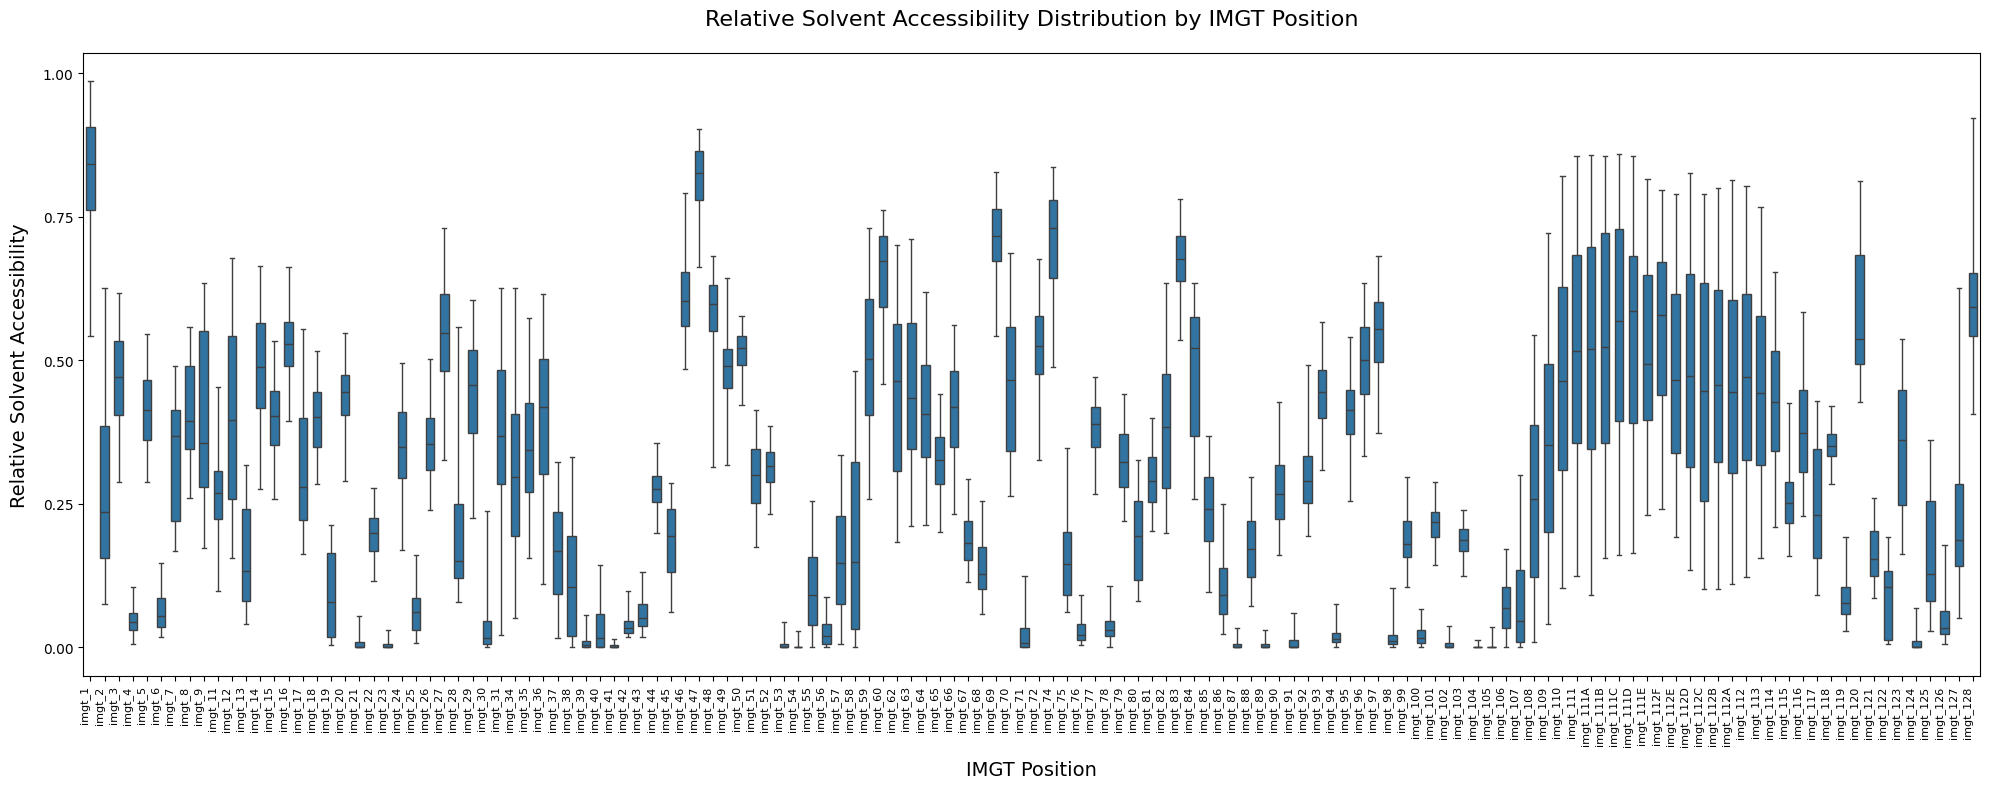

In [ ]:



def plot_imgt_solvent_accessibility(df, filter_stat=None, min_percentage=5):
    """
    Create a boxplot of solvent accessibility across IMGT positions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing the IMGT position columns and solvent accessibility data
    filter_stat : str, optional
        Value to filter the 'stat' column by (e.g., 'rel_asa')
    color_palette : str or list, optional
        Color palette to use for the boxplot (default: 'Blues')
        
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object for further customization or saving
    """
    # Apply filter if specified
    if filter_stat is not None and 'stat' in df.columns:
        df = df[df['stat'] == filter_stat]
    
    # Identify all IMGT position columns - handling both formats: imgt_1 or IMGT_1
    imgt_cols = [col for col in df.columns if col.lower().startswith('imgt_')]
    
    if not imgt_cols:
        raise ValueError("No IMGT position columns found in the dataframe")
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    
    filtered_cols = []
    for col in imgt_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_cols.append(col)

    
    # Convert from wide to long format for seaborn
    df_long = pd.melt(
        df, 
        value_vars=filtered_cols,
        var_name='imgt_position', 
        value_name='solvent_accessibility'
    )
    df_long['solvent_accessibility'] = df_long['solvent_accessibility'].astype(float)

    # Set up the figure with appropriate size
    plt.figure(figsize=(20, 8))
    
    # Create the boxplot
    ax = sns.boxplot(
        x='imgt_position',
        y='solvent_accessibility',
        data=df_long,
        width=0.6,
        fliersize=3,
        linewidth=1,
        showfliers=False,
        whis=(5,95),  # Adjust whiskers to show 90% range
    )
    
    # Customize the plot
    plt.title('Relative Solvent Accessibility Distribution by IMGT Position', fontsize=16, pad=20)
    plt.xlabel('IMGT Position', fontsize=14, labelpad=10)
    plt.ylabel('Relative Solvent Accessibility', fontsize=14, labelpad=10)
    
    # FIXED: Properly set y-ticks using np.linspace
    # Create 5 evenly spaced ticks between 0 and 1
    y_ticks = np.linspace(0, 1, 5)
    ax.set_yticks(y_ticks)
    #ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])  # Format to show one decimal place
    
    # If there are many IMGT positions, rotate the x-axis labels
    if len(imgt_cols) > 10:
        plt.xticks(rotation=90, ha='right', fontsize=8)
    
    # Ensure tight layout
    plt.tight_layout()
    
    medians = df_long.groupby('imgt_position', sort=False)['solvent_accessibility'].median().reset_index()
    medians['imgt_position'] = medians['imgt_position'].str.replace('imgt_', '', case=False)
    for i,j in enumerate('ABCDEFGHIJ'):
        medians['imgt_position'] = medians['imgt_position'].str.replace(j, '.' + str(i+1), case=False)

    return medians

sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')
sa_df_filtered = sa_df = sa_df[(sa_df['organism'] == 'human_ig') & (sa_df['source'] == 'opig-imgt') & (sa_df.chain_type == 'H') & (sa_df['stat'] == 'rel_asa')]
solvent_accessibilities_median_df = plot_imgt_solvent_accessibility(sa_df_filtered[sa_df_filtered['stat'] == 'rel_asa'])

solvent_accessibilities_median_df['imgt_position'] = solvent_accessibilities_median_df['imgt_position'].astype(float)

In [ ]:
sa_df.groupby(['j_family']).size().sort_values().tail(n=20)

j_family
IGHJ1,IGHJ5,IGHJ4,IGHJ6       8
IGHJ8,IGHJ5,IGHJ4,IGHJ3      12
IGHJ2,IGHJ4                  13
IGHJ5,IGHJ4,IGHJ8            15
IGHJ6,IGHJ3                  21
IGHJ1,IGHJ4                  26
IGHJ4,IGHJ3                  26
IGHJ1,IGHJ5                  38
IGHJ2,IGHJ5,IGHJ4            39
IGHJ4,IGHJ6                  44
IGHJ1,IGHJ5,IGHJ4            66
IGHJ5,IGHJ4                  68
IGHJ1,IGHJ5,IGHJ4,IGHJ3      75
IGHJ2                       178
IGHJ5                       281
IGHJ1                       339
IGHJ3                       414
IGHJ6                       553
IGHJ4                       885
unknown                    3254
dtype: int64

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home

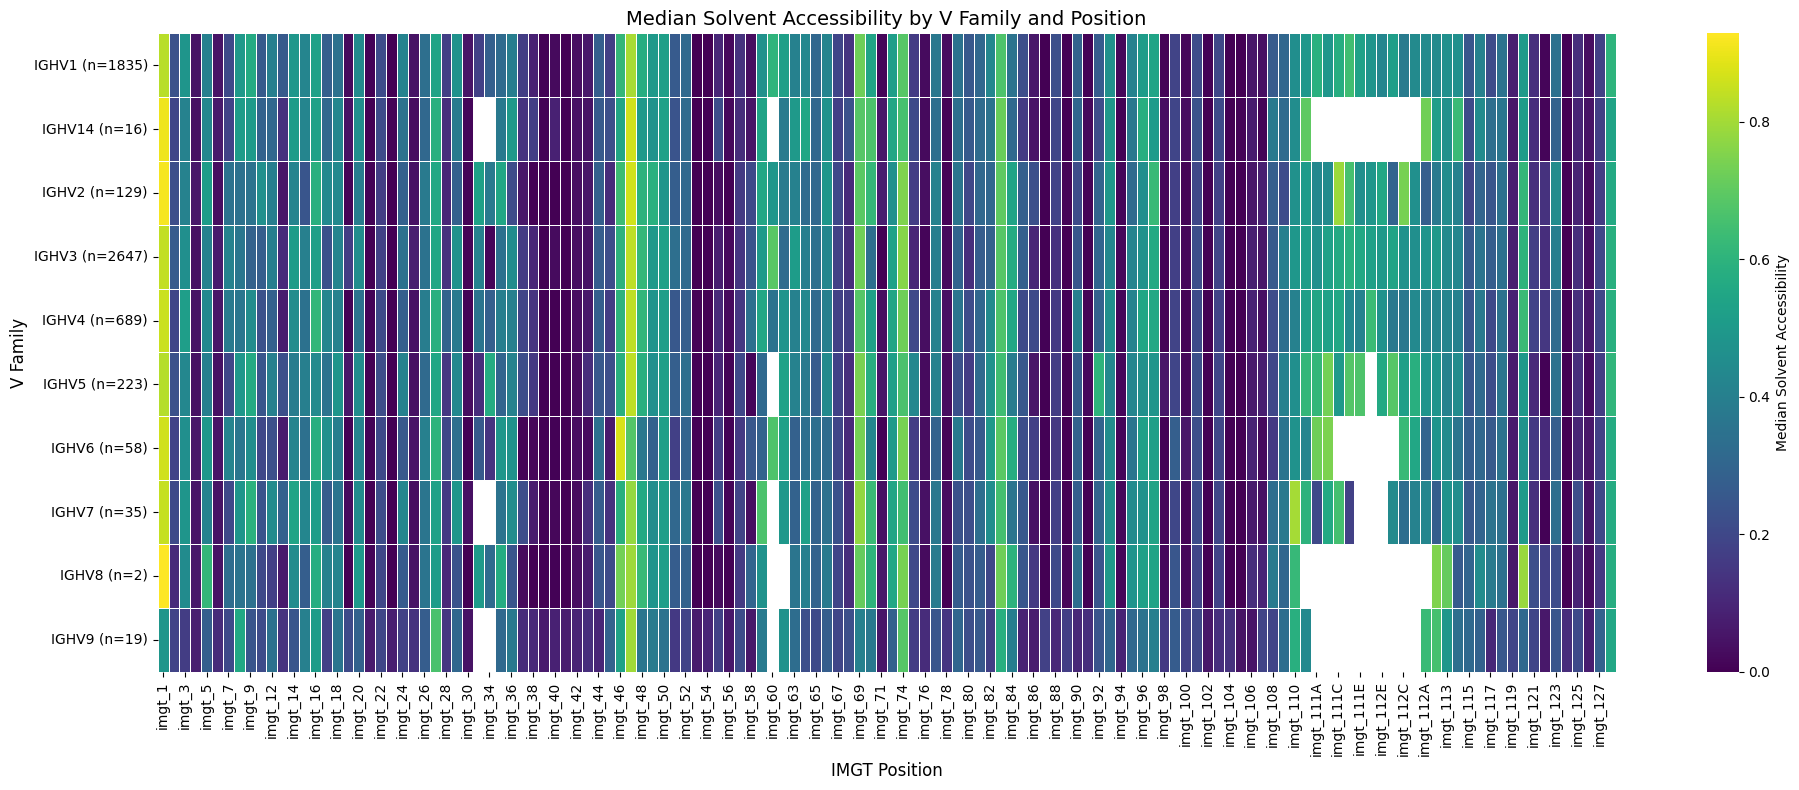

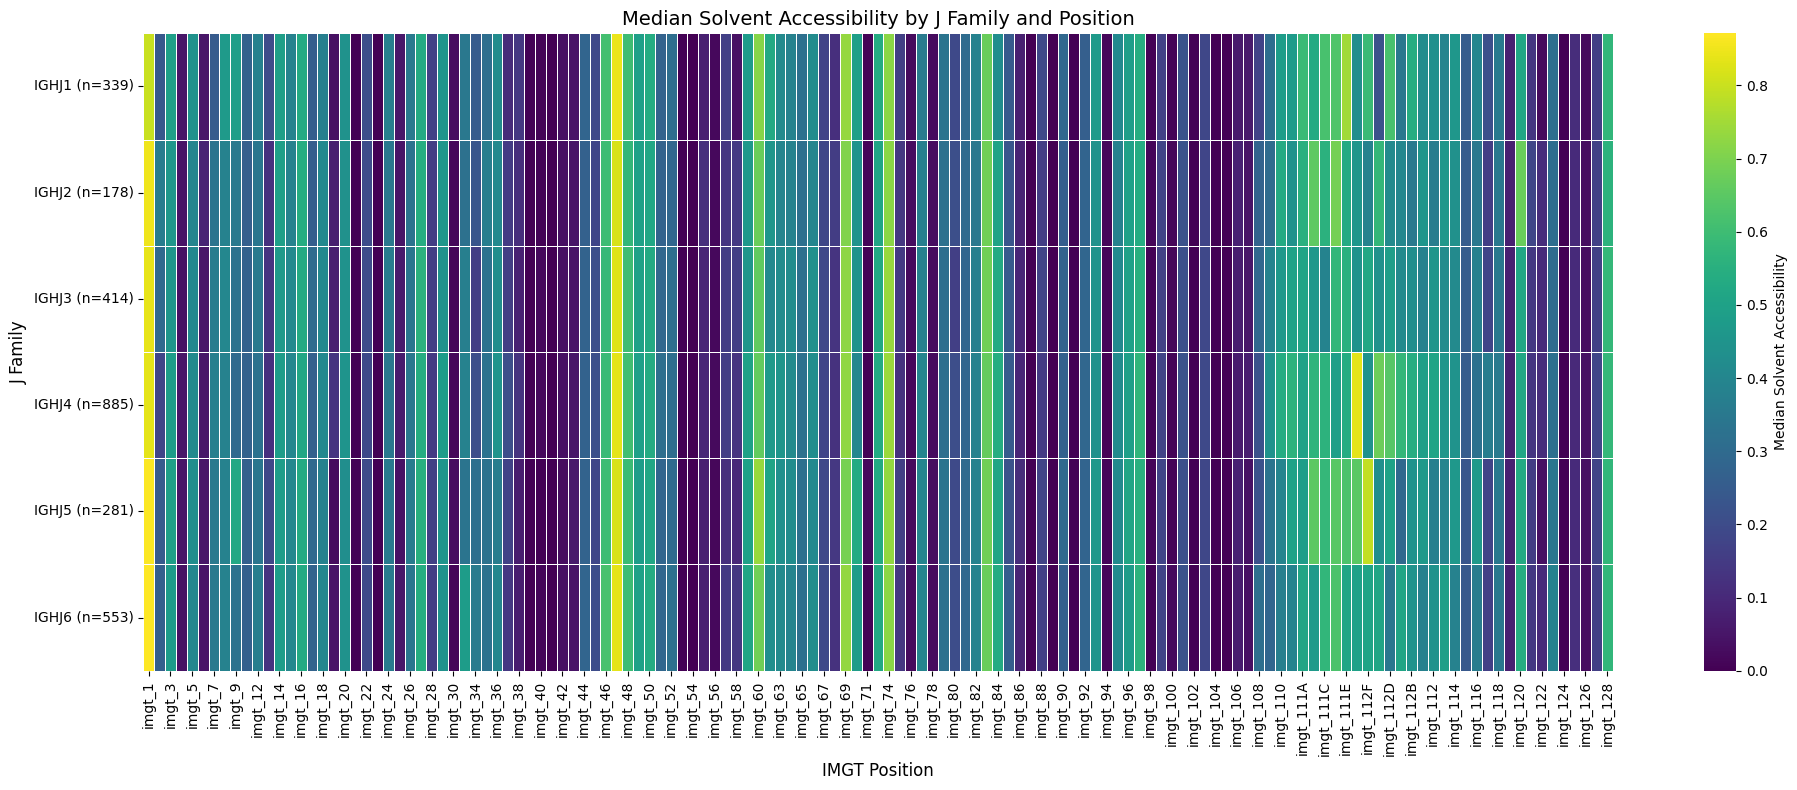

In [ ]:
def create_solvent_accessibility_heatmap(df, position_cols, family_col, value_col='solvent_accessibility', 
                                         figsize=(20, 8), cmap='viridis', title=None, min_percentage=5):
    """
    Creates a heatmap of median solvent accessibility values for different positions across gene families.
    Keeps the original order of position columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing IMGT positions and gene family data
    position_cols : list
        List of column names representing IMGT positions (e.g., 'imgt_1', 'imgt_2', etc.)
    family_col : str
        Column name for the gene family (e.g., 'v_family' or 'j_family')
    value_col : str, optional
        Column name containing the solvent accessibility values, default: 'solvent_accessibility'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 8)
    cmap : str, optional
        Colormap for heatmap, default: 'viridis'
    title : str or None, optional
        Plot title, default: None (auto-generated)
    min_percentage : float, optional
        Minimum percentage of non-null values required for a position column to be included, default: 5
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Make a copy of the DataFrame to avoid modifications to the original
    df = df.copy()

    # filter out rows with ',' in the family column
    df = df[~df[family_col].str.contains(',')]
    df = df[~df[family_col].str.contains('unknown')]
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    filtered_position_cols = []
    for col in position_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_position_cols.append(col)
    
    # Use the filtered position columns
    position_cols = filtered_position_cols
    
    # Convert string columns to numeric
    for col in position_cols:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Reshape the data for the heatmap
    result_data = []
    
    # Get unique families
    families = df[family_col].unique()
    
    # For each position column, calculate median value per family
    for pos_col in position_cols:
        pos_name = pos_col  # Extract just the position name/number
        
        for family in families:
            # Filter data for this family
            family_data = df[df[family_col] == family]
            
            # Calculate median value for this position and family
            median_value = family_data[pos_col].median()
            
            # Add to result data
            result_data.append({
                'Position': pos_name,
                'Family': family,
                'Median_Value': median_value
            })
    
    # Create a dataframe from the results
    result_df = pd.DataFrame(result_data)
    
    # Pivot the data for the heatmap
    pivot_df = result_df.pivot(index='Family', columns='Position', values='Median_Value')
    
    # Reorder columns to maintain original order from position_cols
    # This is the key change to preserve the original column order
    pivot_df = pivot_df.reindex(columns=position_cols)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the heatmap
    sns.heatmap(pivot_df, cmap=cmap, ax=ax, 
                cbar_kws={'label': f'Median {value_col.replace("_", " ").title()}'},
                linewidths=0.5)
    
    # Generate title if not provided
    if title is None:
        title = f'Median {value_col.replace("_", " ").title()} by {family_col.replace("_", " ").title()} and Position'
    
    # Add labels and title
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('IMGT Position', fontsize=12)
    ax.set_ylabel(family_col.replace('_', ' ').title(), fontsize=12)
    
    # Calculate the number of families analyzed
    family_counts = df[family_col].value_counts()
    
    # Modify the y-tick labels to include the count of samples per family
    ylabels = [f"{family} (n={family_counts[family]})" for family in pivot_df.index]
    ax.set_yticklabels(ylabels, rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

# Assuming df is your dataframe and contains columns like 'imgt_1', 'imgt_2', etc., 'v_family', and 'solvent_accessibility'
position_cols = [col for col in sa_df_filtered.columns if col.startswith('imgt_')]

# # For V families
fig_v, ax_v = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'v_family')

# # For J families
fig_j, ax_j = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'j_family')